In [1]:
#This file allows to go through all the files of borehole MB1, plot the ATV

In [1]:
import os

#path_to_data, files = download_VALTER_borehole('MB1')

#if the files have already been downloaded use the command as following
path_to_data = r"C:\Users\StartKlar\Documents\Msc_Thesis\Data\New_datasets_HS\CB1" + os.sep
files = os.listdir(path_to_data)
print(files)
# show the list of files in the folder as well as their number
print(len(files))


['CB1_ATV_20200513.las', 'CB1_ATV_centralized_20191010.las', 'CB1_OTV_20191010.las', 'CB1_OTV_ATV_Structure_Interp.csv', 'CB1_OTV_ATV_Structure_Interp.xlsx']
5


### Import the necessary functions to read the data
showing the "path_to_data" allows to make sure that it is well downloaded in your own computer, without any error.
Then import the necessary functions to read the ATV and OTV data (importLASv3.py). The star allows to import all the functions from the file.

In [2]:
from deeplogger.importLASv3 import *
#as following, you will find the list of files for borehole MB1, as well as the depths covered by each individual file.

##Best File to analyse the data : 
file_atv_am =files[0] #am for the amplitude file to 295m of borehole MB1, the minimum depth of the file is 0.5 m.
file_atv_tt = files[4] #tt for the amplitude file to 295m of borehole MB1, the minimum depth of the file is 0.5 m. 
    ##sharp transition between 119.25 and 119.75m

##In the following files, the trace of the ATV-tool is very dark on the image. Therefore, applying filtering does not allow to recreate whole fractures traces.
#file_atv_am =files[6] #am for the amplitude file to 300m of borehole MB1, the minmum depth of the file is 119.25m and the maximum depth is 119.75m 
#file_atv_tt = files[7] #tt for the amplitude file to 300m of borehole MB1
    ##sharp transition between 119.25 and 119.75m
 
##The Acoustic Televiewer images from the following files are of lower resolution than 365 degrees (357.5 deg.), hence, the machine learning could not be so efficient on them.
#file_atv_am =files[3] #am for the amplitude file to 295m of borehole MB1, the minimum depth of the file is 0 m
#file_atv_tt = files[5] #tt for the amplitude file to 295m of borehole MB1, the minimum depth of the file is 0 m 
#Bad quality of data, resolution below 365 degrees.

##The following file only covers depths from 292.273 m to 295.535 m. Therefore, the probablity to find any discontinuity feature is low. The only fracture can be found from 295m to 295.5m on the ATV files, and form 294.5 to 295 m for the OTV file.
#file_atv_am =files[2] #am for the amplitude file from 292.273 to 295.535 m. 
#file_atv_tt = files[8] #tt for the amplitude file from 292 to 295 m.

#### Load the OTV and compare it to the ATV data

C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\interna

([], [])

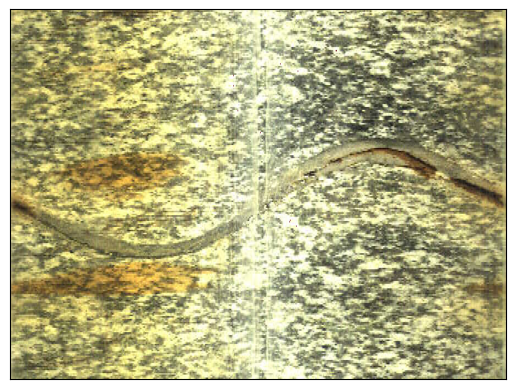

In [3]:
#Load OTV data and remove the empty measurements
from matplotlib import pyplot as plt

from deeplogger.image_processing import *
file_name = files[2]
depth_vector, first_dataline = get_depth_only(file_name=file_name, data_path=path_to_data)

data_subset, index = get_data_subset_from_depth_range(file_name=file_name,
                                                                    data_path=path_to_data,
                                                                    depth=depth_vector,
                                                                    data_type='otv',
                                                                    depth_range=[124.30,124.80 ])



data_subset = replace_empty_measurements(data_subset, 0)
plt.imshow(data_subset, aspect='auto', extent=[0, 359,124.70, 124.20])
plt.yticks([])  # Removes y-axis ticks
plt.xticks([])


([], [])

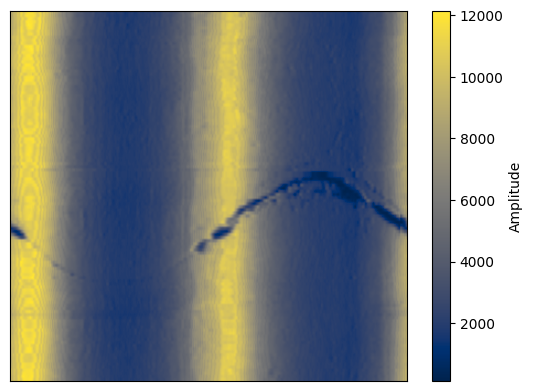

In [27]:
from deeplogger.image_processing import *
depth_vector_atv, first_dataline_atv = get_depth_only(file_name=file_atv_am, data_path=path_to_data)


data_subset_atv,  index_atv = get_data_subset_from_depth_range(file_name=file_atv_am,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth=depth_vector_atv,
                                                                    depth_range=[124.50, 125.00])
#take-off the zero values within the data subset
data_subset_atv = replace_empty_measurements(data_subset_atv, 0)
plt.imshow(data_subset_atv, cmap='cividis', aspect='auto')
cbar = plt.colorbar()
cbar.set_label('Amplitude')
plt.yticks([])  # Removes y-axis ticks
plt.xticks([])

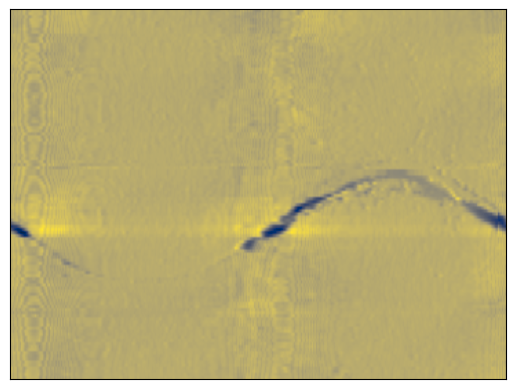

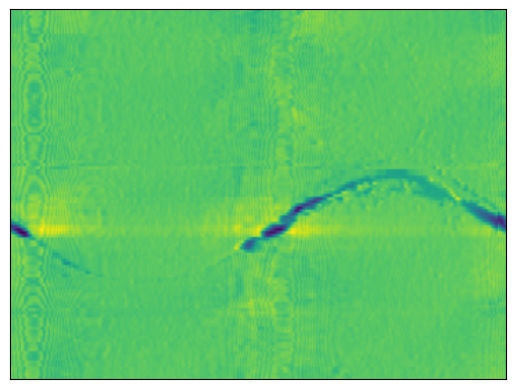

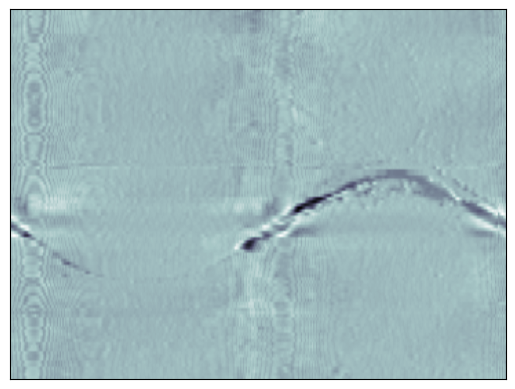

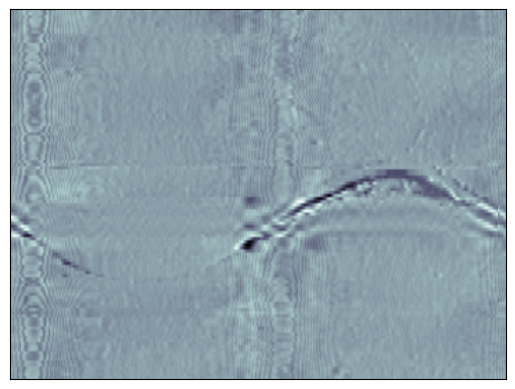

In [29]:
data_subset_svd_1, svd_decomp_am = remove_svd(data_subset_atv, low_s=0, high_s=1)
data_subset_svd_2, svd_decomp_am = remove_svd(data_subset_atv, low_s=0, high_s=2)
data_subset_svd_3, svd_decomp_am = remove_svd(data_subset_atv, low_s=0, high_s=3)
data_subset_svd_4, svd_decomp_am = remove_svd(data_subset_atv, low_s=0, high_s=4)
data_subset_svd_5, svd_decomp_am = remove_svd(data_subset_atv, low_s=0, high_s=5)

plt.imshow(data_subset_svd_1, cmap='cividis', aspect='auto')
plt.yticks([])  # Removes y-axis ticks
plt.xticks([])
plt.show()
plt.imshow(data_subset_svd_1, cmap='viridis', aspect='auto')
plt.yticks([])  # Removes y-axis ticks
plt.xticks([])
plt.show()
# plt.imshow(data_subset_svd_2, cmap='viridis', aspect='auto')
# plt.yticks([])  # Removes y-axis ticks
# plt.xticks([])
# plt.show()

plt.imshow(data_subset_svd_3, cmap='bone', aspect='auto')
plt.yticks([])  # Removes y-axis ticks
plt.xticks([])
plt.show()

# plt.imshow(data_subset_svd_4, cmap='viridis', aspect='auto')
# plt.yticks([])  # Removes y-axis ticks
# plt.xticks([])
# plt.show()

plt.imshow(data_subset_svd_5, cmap='bone', aspect='auto')
plt.yticks([])  # Removes y-axis ticks
plt.xticks([])
plt.show()



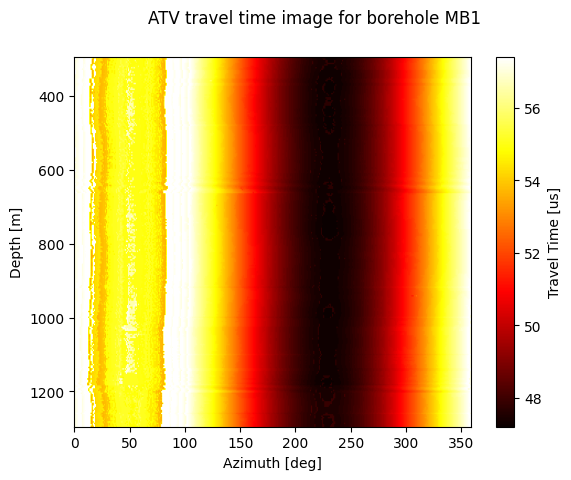

In [49]:
#same but with travel time
depth_ATV_tt = get_depth_only(file_name=file_atv_tt,
               data_path=path_to_data)

depth_subset_ATV_tt, data_subset_ATV_tt, index = get_data_subset_from_depth_range(file_name=file_atv_tt,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[295, 295.535])
#take-off the zero values
data_subset_ATV_tt = replace_empty_measurements(data_subset_ATV_tt, 0)
plt_ATV_tt = plot_atv_tt(data_subset_ATV_tt, figure_limits=[0, 359,1295.535, 295], cmap='hot', title= "ATV travel time image for borehole MB1")

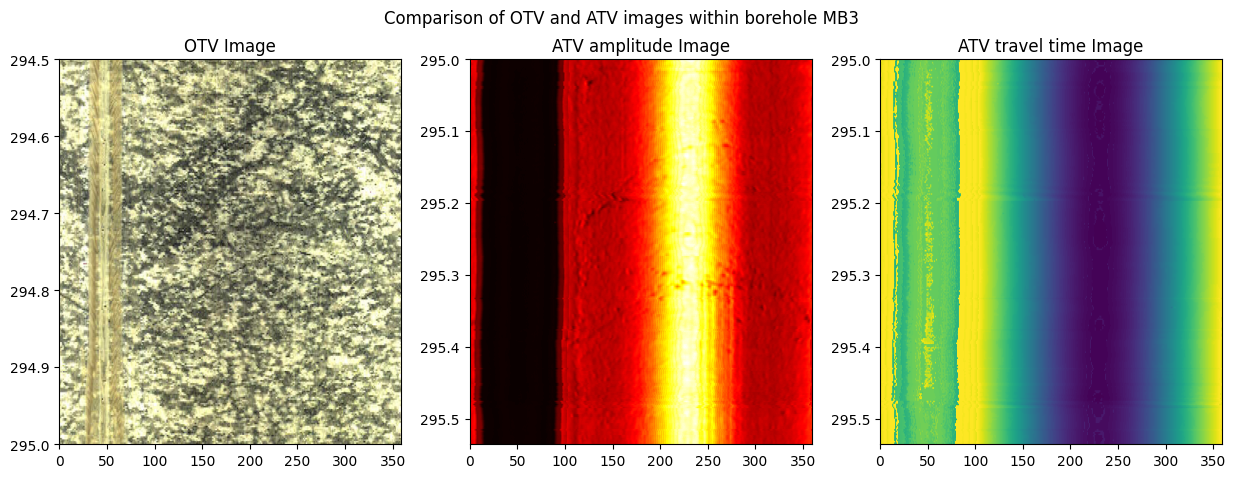

In [50]:
#compare the three plots ad note the differences
import matplotlib.pyplot as plt

# Assuming you have defined your plot_atv function
# and data_subset_ATV_am, data_subset_ATV_tt are your data subsets

# Create a figure and three subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Adjust the figure size as needed

# Plot the first image with the colormap 'viridis'
plt_OTV = axs[0].imshow(data_subset, aspect='auto', extent=[0, 359, 295,294.5], cmap='viridis')
# Plot the second image with the default colormap (original)
plt_ATV_am = axs[1].imshow(data_subset_ATV_am, aspect='auto', extent=[0, 359, 295.535, 295], cmap='hot')
# Plot the third image with the default colormap (original)
plt_ATV_tt = axs[2].imshow(data_subset_ATV_tt, aspect='auto', extent=[0, 359, 295.535, 295], cmap='viridis')

# Add titles to each subplot
axs[0].set_title('OTV Image')
axs[1].set_title('ATV amplitude Image')
axs[2].set_title('ATV travel time Image')

# Add a common title for the entire figure
fig.suptitle('Comparison of OTV and ATV images within borehole MB3')

# Show the figure
plt.show()


### Apply the filtering

#### SVD filtering
It is one of the most well-used tools for data processing. It is defined as reduction tool used for high dimensional and resolution data. The SVD will reduce it into the key features which allow to describe and analyse the data.
The singular value decomposition processes a matrix and outputs it into 3 different matrices. Each matrix has a constraint. The SVD theorem says it’s always possible to decompose a real (real =/complex numbers) matrix into these 3, as well as re-transpose. U: Left singular vectors ; R: diagonal matrix, it has 0 everywhere except for the diagonal, where there are, what are called, singular values. These are sorted in the decreasing order. V:  Right singular vectors 
U and V are column orthonormal. 
 
In this case, SVD filtering is applied to the ATV data. The function remove_svd allows to remove the svd part of the data. The low_s and high_s parameters allow to set the limits of the svd to remove. The svd_decomp variable allows to plot the svd part of the data.

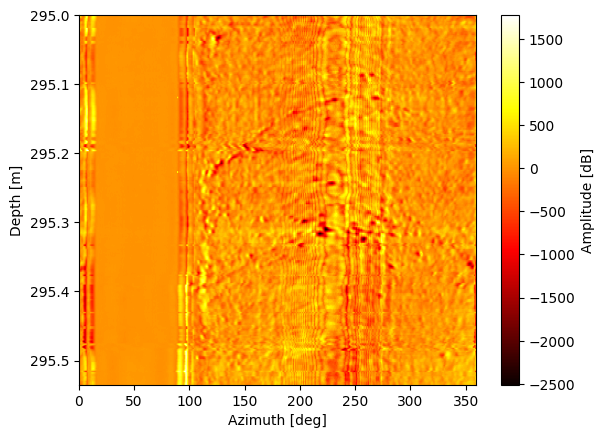

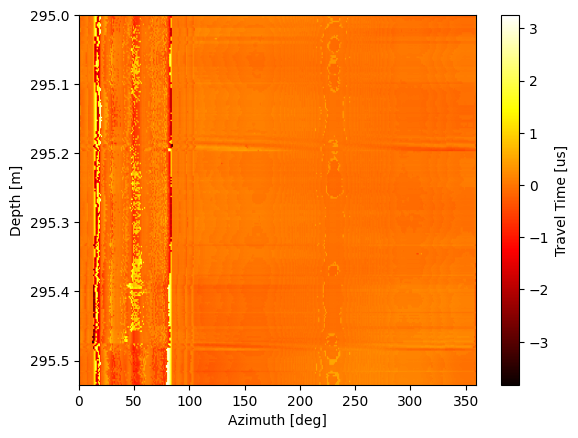

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [51]:
from deeplogger.image_processing import *
from deeplogger.plotting import *


# Apply SVD and plot the filtered data
# function returns the input data without the svd part and the svd part that is removed
# you can set the limits of the svd to remove by setting the low_s and high_s parameters
data_subset_svd_am = data_subset_svd_am, svd_decomp_am = remove_svd(data_subset_ATV_am, low_s=0, high_s=1)
# plot the data without the svd part
plot_atv_am(data_subset_svd_am, figure_limits=[0, 359,295.535, 295])

##same with the travel time data 
data_subset_svd_tt = data_subset_svd_tt, svd_decomp_tt = remove_svd(data_subset_ATV_tt, low_s=0, high_s=1)
# plot the data without the svd part
plot_atv_tt(data_subset_svd_tt, figure_limits=[0, 359,295.535, 295])

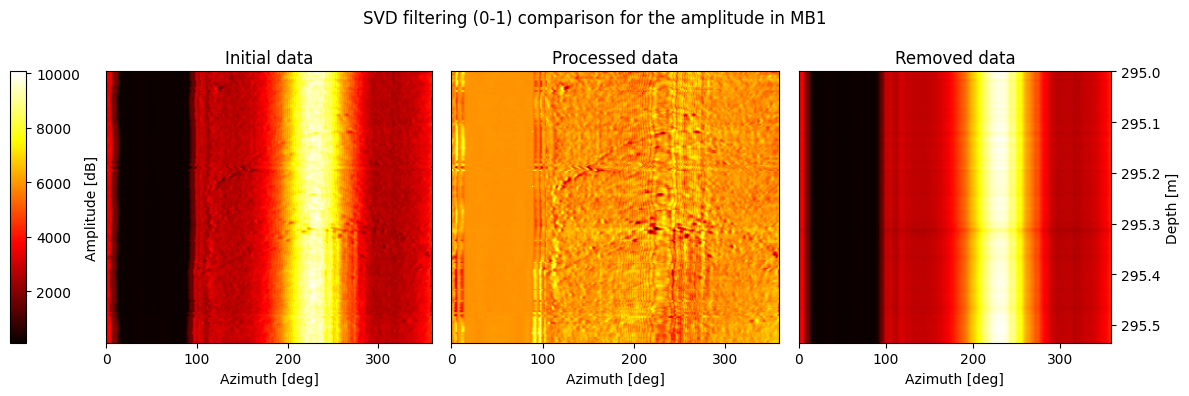

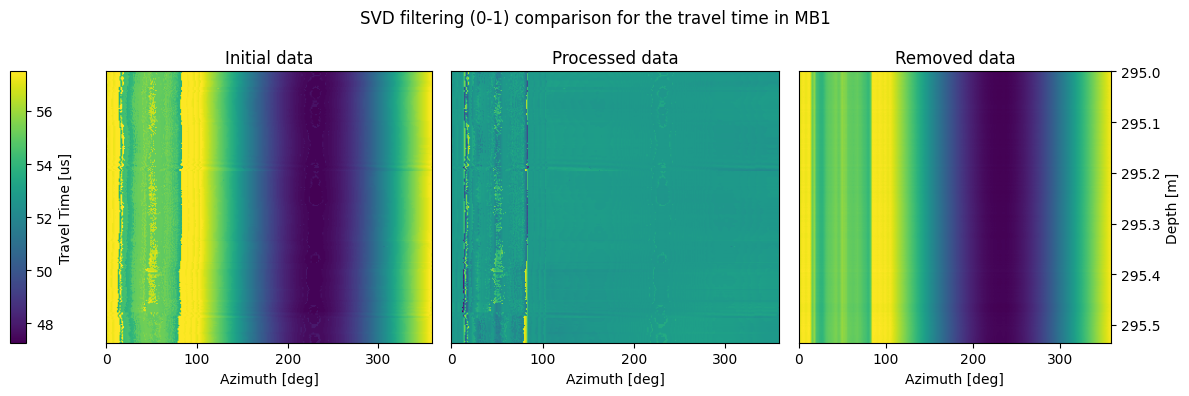

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: title={'center': 'Initial data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Processed data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Removed data'}, xlabel='Azimuth [deg]', ylabel='Depth [m]'>],
       dtype=object))

In [52]:
#plot a comparison of the image with and without the svd part, as well as the removed svd part
plot_comparison_am(data_subset_ATV_am,
                data_subset_svd_am,
                svd_decomp_am,   
                figure_limits=[0, 359,295.535, 295], 
                title='SVD filtering (0-1) comparison for the amplitude in MB1')
plot_comparison_tt(data_subset_ATV_tt,
                data_subset_svd_tt,
                svd_decomp_tt,   
                figure_limits=[0, 359,295.535, 295], 
                title='SVD filtering (0-1) comparison for the travel time in MB1',
                cmap='viridis')

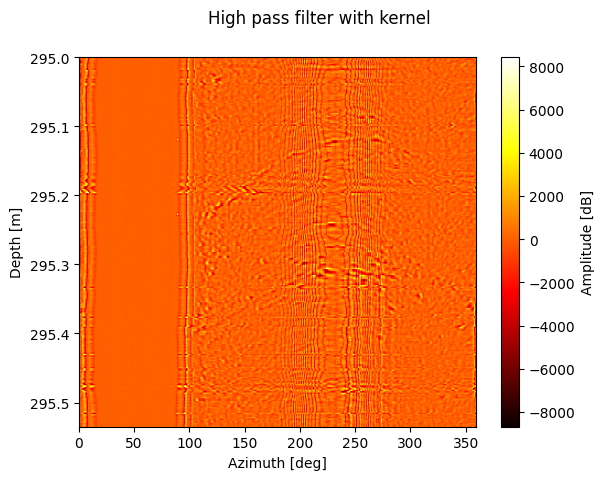

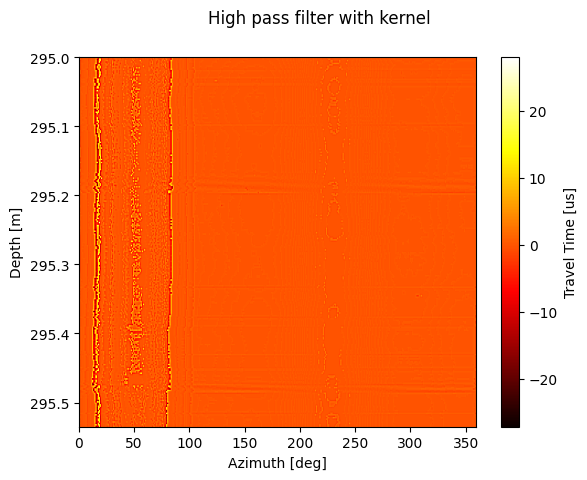

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [53]:
#apply the high pass filter with kernel and plot the result
hpass_am = high_pass_2D_kernel(data_subset_ATV_am)
plot_atv_am(hpass_am,
         cmap='hot',
         figure_limits=[0, 359,295.535, 295], 
         title='High pass filter with kernel')
#same for travel time
hpass_tt = high_pass_2D_kernel(data_subset_ATV_tt)
plot_atv_tt(hpass_tt,
         cmap='hot',
         figure_limits=[0, 359,295.535, 295], 
         title='High pass filter with kernel')




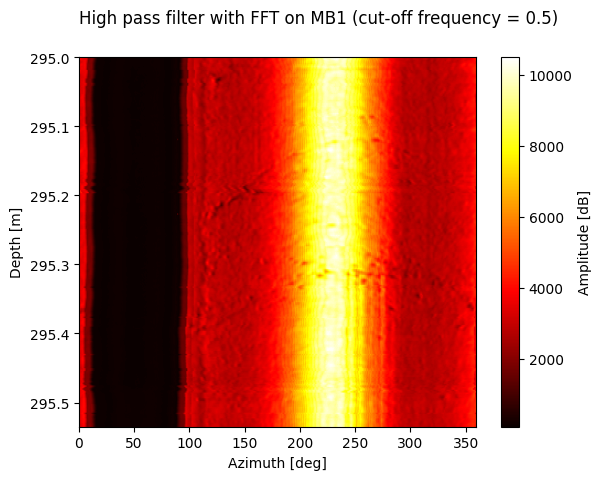

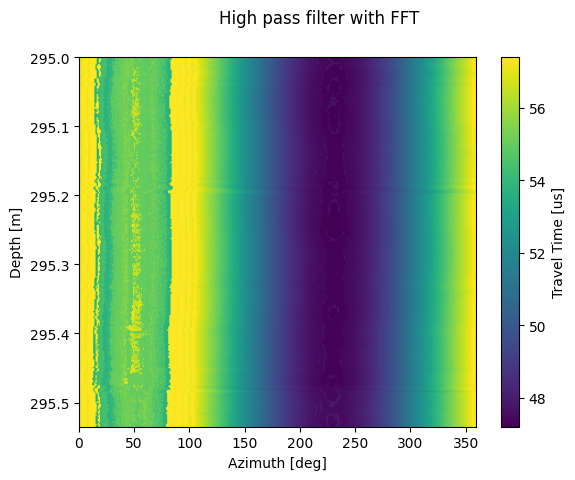

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [55]:
#Apply the high-pass filter with fft and plot the result
hpass_fft = high_pass_FFT_2D(data_subset_ATV_am, cutoff_frequency=0.5)
plot_atv_am(hpass_fft,
         cmap='hot',
         figure_limits=[0, 359,295.535, 295], 
         title='High pass filter with FFT on MB1 (cut-off frequency = 0.5)')

#same for travel time
hpass_fft = high_pass_FFT_2D(data_subset_ATV_tt, cutoff_frequency=0.5)
plot_atv_tt(hpass_fft,
         cmap='viridis',
         figure_limits=[0, 359,295.535, 295], 
         title='High pass filter with FFT')

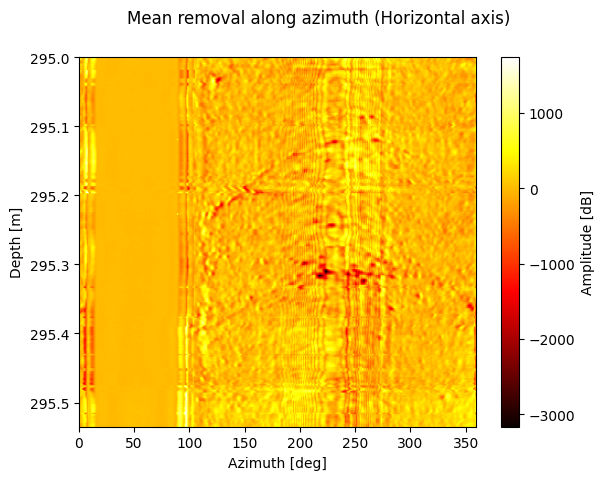

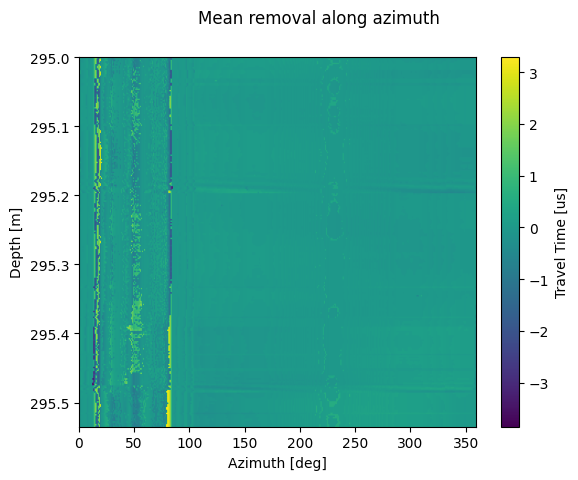

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Azimuth [deg]', ylabel='Depth [m]'>)

In [56]:

test = mean_removal_x, removed_data = remove_mean(data_subset_ATV_am, axis=0)
plot_atv_am(mean_removal_x,
         cmap='hot',
         figure_limits=[0, 359,295.535, 295], 
         title='Mean removal along azimuth (Horizontal axis)')

mean_removal_x, removed_data = remove_mean(data_subset_ATV_tt, axis=0)
plot_atv_tt(mean_removal_x,
         cmap='viridis',
         figure_limits=[0, 359,295.535, 295], 
         title='Mean removal along azimuth')

# Conclusion on the best way to apply mean removal
By comparing the removal means either along the lines, columns or both, the stripes from the televiewer are more accentuated when applying the mean removal vertically, along the columns. Hence, it is more relevant to apply the mean removal along the lines, as it allows to remove the stripes from the televiewer.

<img src="/Users/palomaperritaz/Desktop/MB1_24_25_mean1.png" alt="Alternative text" />
<img src="/Users/palomaperritaz/Desktop/MB1_24_25_mean_2.png" alt="Alternative text" />
<img src="/Users/palomaperritaz/Desktop/MB1_24_25_mean0.png" alt="Alternative text" />



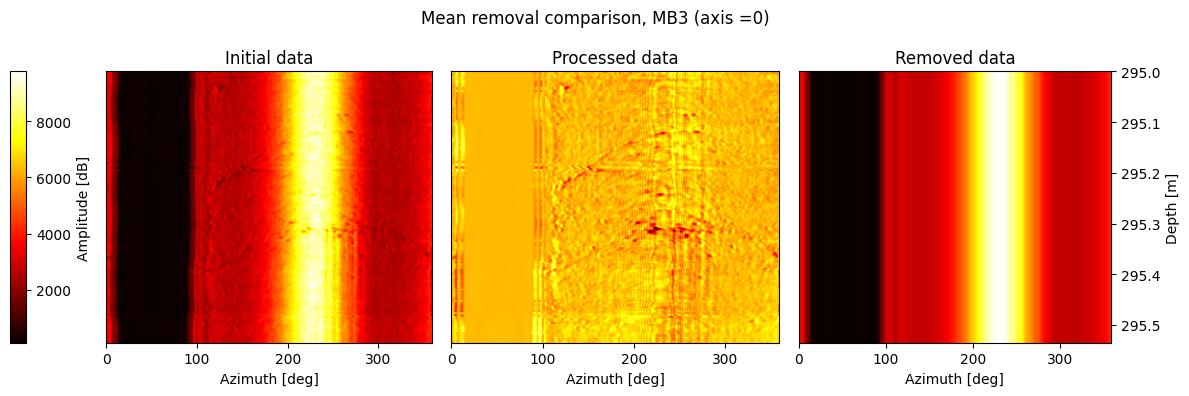

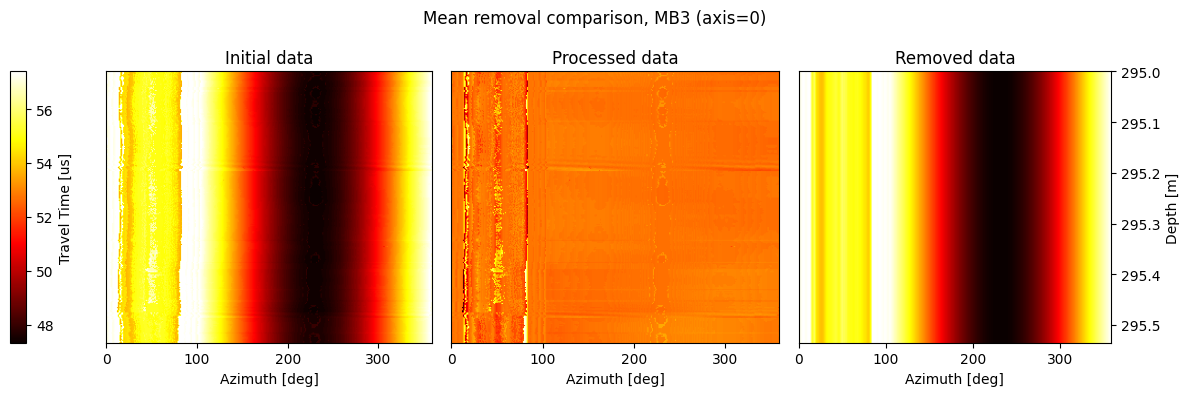

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: title={'center': 'Initial data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Processed data'}, xlabel='Azimuth [deg]'>,
        <Axes: title={'center': 'Removed data'}, xlabel='Azimuth [deg]', ylabel='Depth [m]'>],
       dtype=object))

In [58]:
##plot a comparison of before and after the high-pass filtering
mean_removal_both, removed_data = remove_mean(data_subset_ATV_am, axis=0)

plot_comparison_am(data_subset_ATV_am,
                mean_removal_both,
                removed_data,   
                figure_limits=[0, 359,295.535, 295], 
                title='Mean removal comparison, MB3 (axis =0)')
#same for travel time
mean_removal_both, removed_data = remove_mean(data_subset_ATV_tt, axis=0)

plot_comparison_tt(data_subset_ATV_tt,
                mean_removal_both,
                removed_data,   
                figure_limits=[0, 359,295.535, 295], 
                title='Mean removal comparison, MB3 (axis=0)',
                cmap='hot')